# **Ciência de Dados em Larga Escala**

**Project: Performance Analysis**

In this notebook, we present the results obtained from the performance benchmarking of different machine learning and data processing libraries across separate experiments: **Dask+Modin, Dask+Rapids, Dask and Koalas**.

In [ ]:
from datetime import datetime
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Loading the results files**

In [ ]:
# Define task names
task = [
    'read file', 'count', 'count index length', 'mean', 'standard deviation',
    'mean of columns addition', 'addition of columns', 'mean of columns multiplication',
    'multiplication of columns', 'value counts', 'complex arithmetic ops',
    'mean of complex arithmetic ops', 'groupby statistics', 'join count', 'join'
]

In [ ]:
# Dataset sizes and libraries
sizes = ['small', 'medium', 'large']
variants = ['standard', 'filtered', 'cache']
libraries = ['koalas', 'dask', 'modin', 'joblib', 'rapids']

In [ ]:
# Mapping of DataFrame variables to metadata
data_map = {
    'koalas': {
        'small': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_S/koalas_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_S/koalas_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_S/koalas_local_cache"),
        },
        'medium': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_M/koalas_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_M/koalas_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_M/koalas_local_cache"),
        },
        'large': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_L/koalas_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_L/koalas_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_L/koalas_local_cache"),
        }
    },
    'dask': {
        'small': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_S/dask_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_S/dask_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_S/dask_local_cache"),
        },
        'medium': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_M/dask_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_M/dask_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_M/dask_local_cache"),
        },
        'large': {
            'standard': pd.read_parquet("Koalas_Dask_Local/Results_L/dask_local"),
            'filtered': pd.read_parquet("Koalas_Dask_Local/Results_L/dask_local_filtered"),
            'cache': pd.read_parquet("Koalas_Dask_Local/Results_L/dask_local_cache"),
        }
    },
    'modin': {
        'small': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Modin/modin_local_small"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Modin/modin_filtered_local_small"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Modin/modin_cache_local_small"),
        },
        'medium': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Modin_M/modin_local_medium"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Modin_M/modin_filtered_local_medium"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Modin_M/modin_cache_local_medium"),
        },
        'large': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Modin_L/modin_local_large"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Modin_L/modin_filtered_local_large"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Modin_L/modin_cache_local_large"),
        }
    },
    'joblib': {
        'small': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Joblib/joblib_local_small"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Joblib/joblib_filtered_local_small"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Joblib/joblib_cache_local_small"),
        },
        'medium': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Joblib_M/joblib_local_medium"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Joblib_M/joblib_filtered_local_medium"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Joblib_M/joblib_cache_local_medium"),
        },
        'large': {
            'standard': pd.read_parquet("Modin_Joblib/Results_Joblib_L/joblib_local_large"),
            'filtered': pd.read_parquet("Modin_Joblib/Results_Joblib_L/joblib_filtered_local_large"),
            'cache': pd.read_parquet("Modin_Joblib/Results_Joblib_L/joblib_cache_local_large"),
        }
    }
}

In [ ]:
# Flatten all into one DataFrame
records = []
for lib, lib_data in data_map.items():
    for size, size_data in lib_data.items():
        for variant, df in size_data.items():
            df = df.reset_index()
            for _, row in df.iterrows():
                records.append({
                    'library': lib,
                    'size': size,
                    'variant': variant,
                    'task': row['task'],
                    'duration': row['duration']
                })

df_all = pd.DataFrame(records)

In [ ]:
df_all

,library,size,variant,task,duration
0,koalas,small,standard,read file,0.206737
1,koalas,small,standard,count,0.169843
2,koalas,small,standard,count index length,0.139787
3,koalas,small,standard,mean,0.168816
4,koalas,small,standard,standard deviation,0.179950
...,...,...,...,...,...
532,joblib,large,cache,complex arithmetic ops,0.004669
533,joblib,large,cache,mean of complex arithmetic ops,0.005061
534,joblib,large,cache,groupby statistics,0.003320
535,joblib,large,cache,join count,0.002418


# Results Analysis

**Grouped bar charts**

A series of grouped bar charts (also known as clustered bar plots) was generated using the Seaborn library.

In each chart, the x-axis represents different computational tasks (e.g., mean calculation, joins), and the y-axis shows the execution duration in seconds.

For each task, multiple bars are grouped side by side, each one corresponding to a different data processing library (e.g., Dask, Koalas, Modin, Rapids).

The color of each bar is set using a custom palette to differentiate the libraries visually.

The plots are segmented by dataset size **(small, medium, large)** and variant **(standard dataset, filtered, cached)**, which allows to observe how the performance varies under different data volumes and processing contexts.

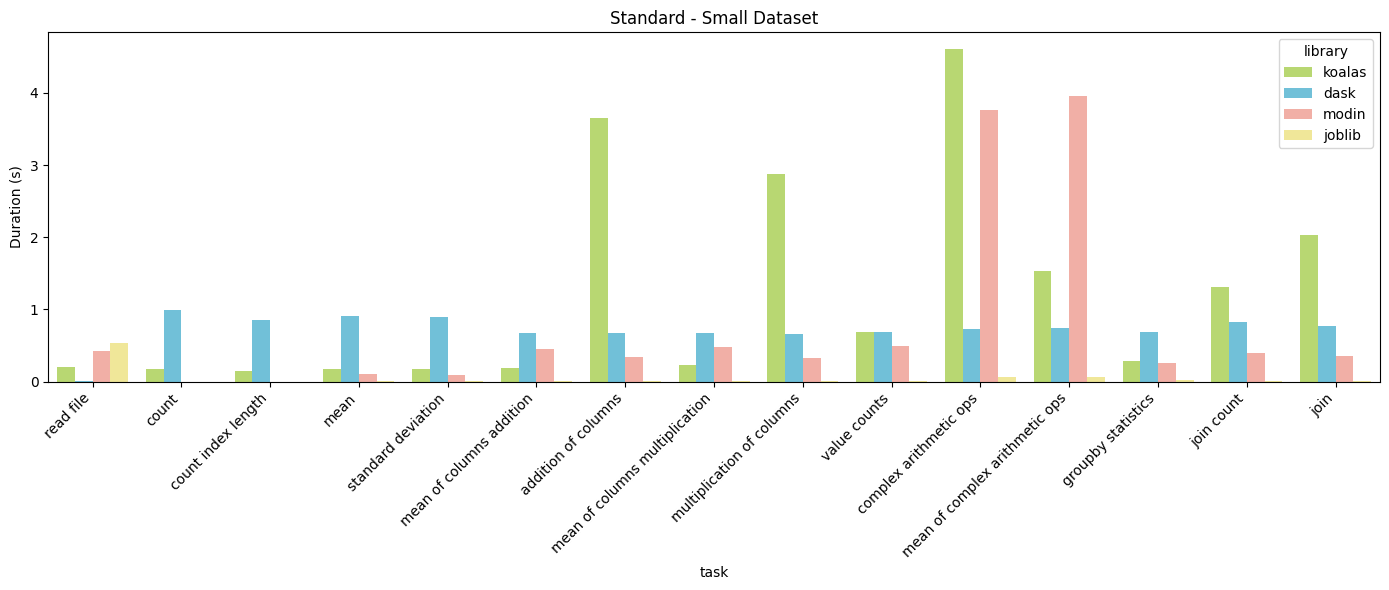

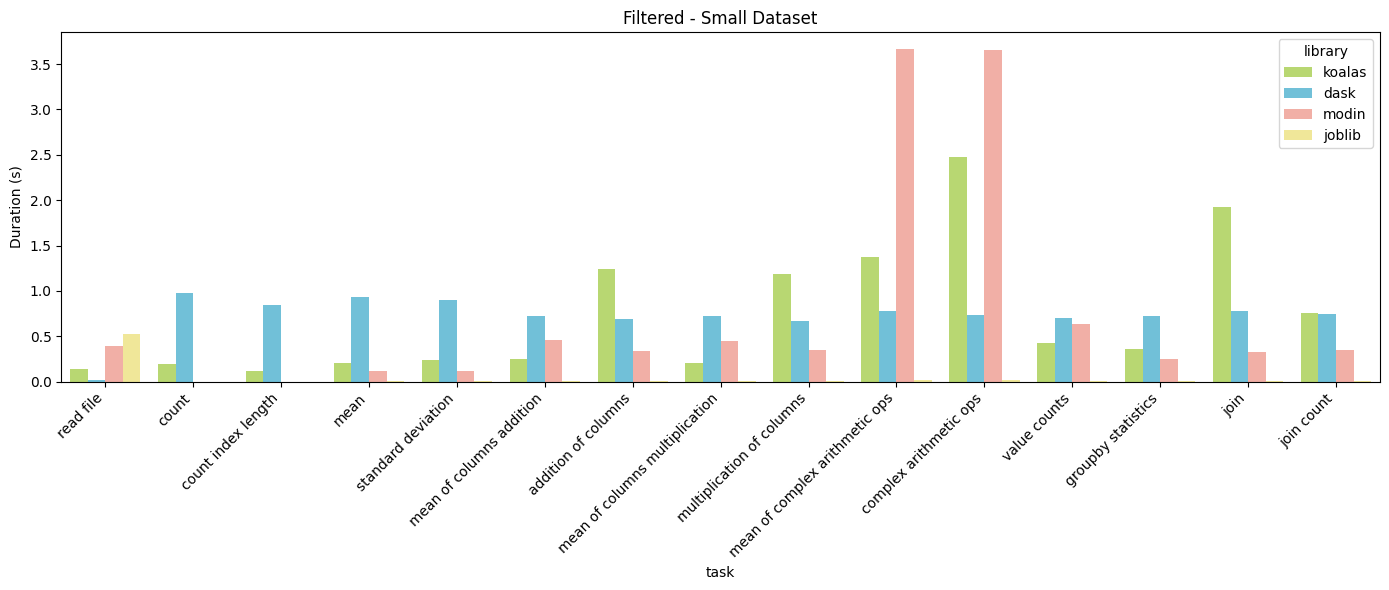

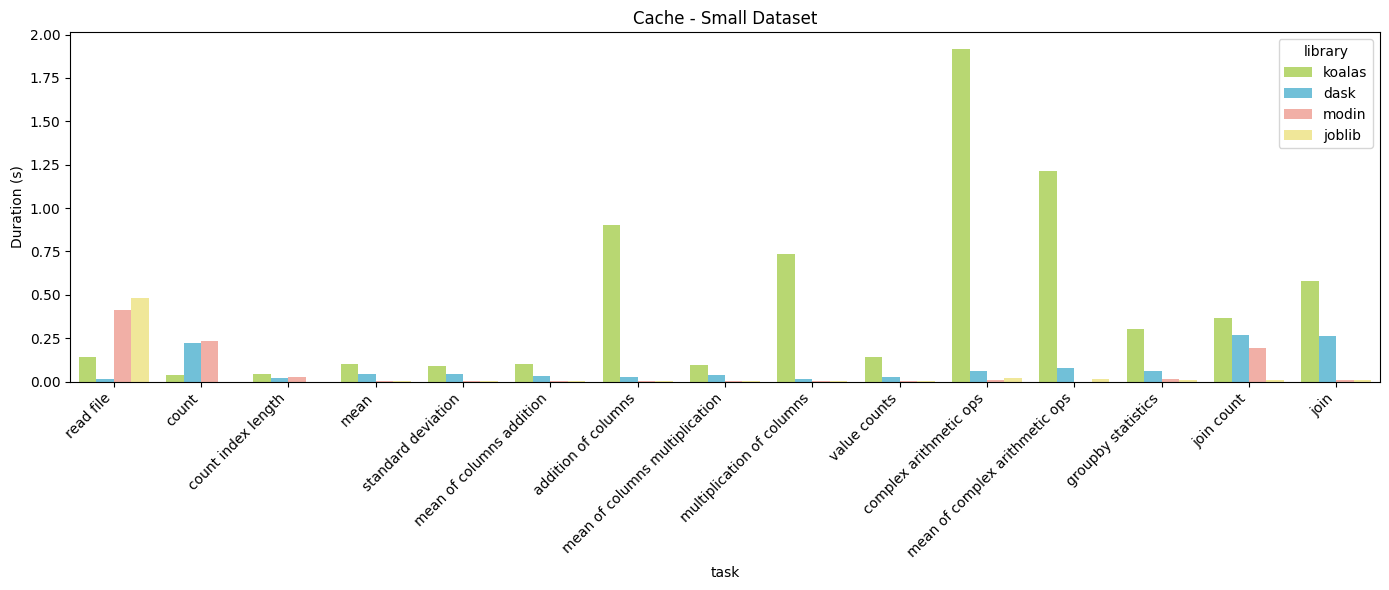

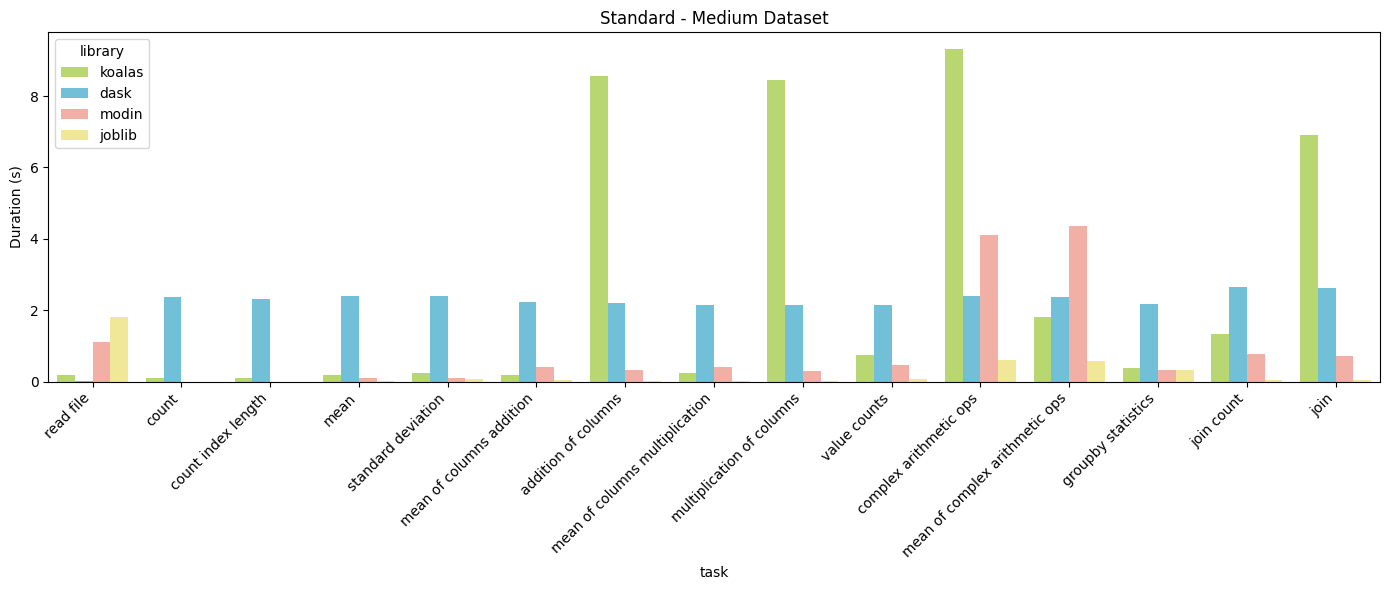

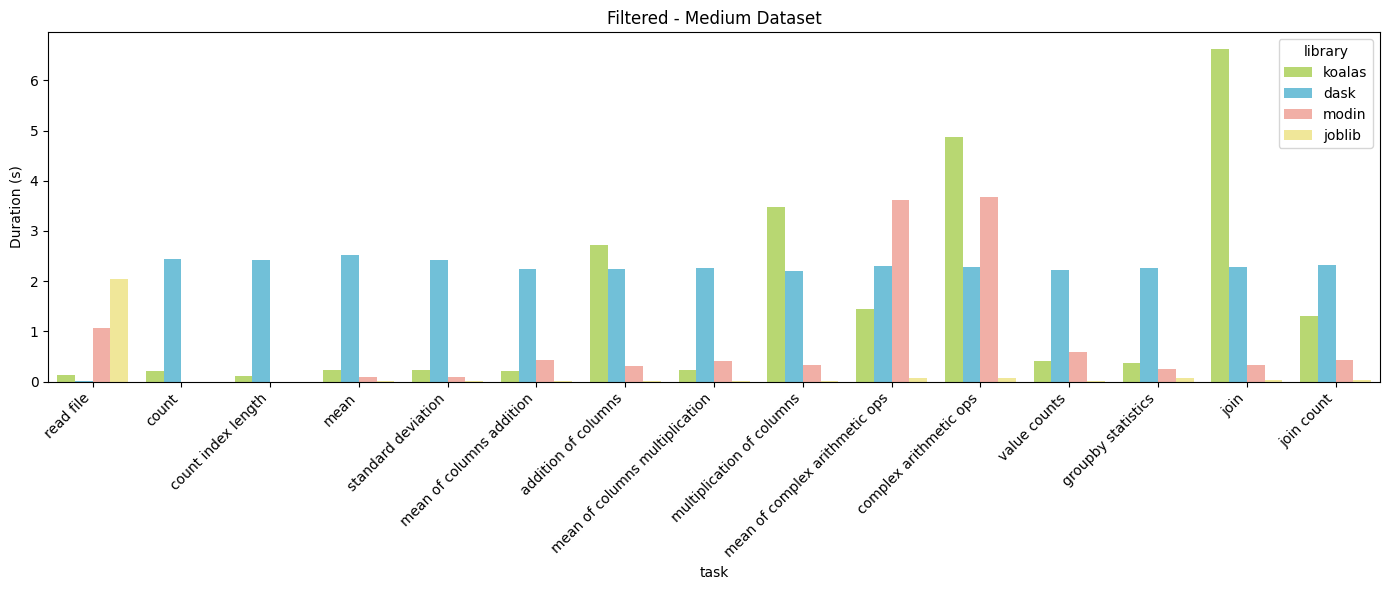

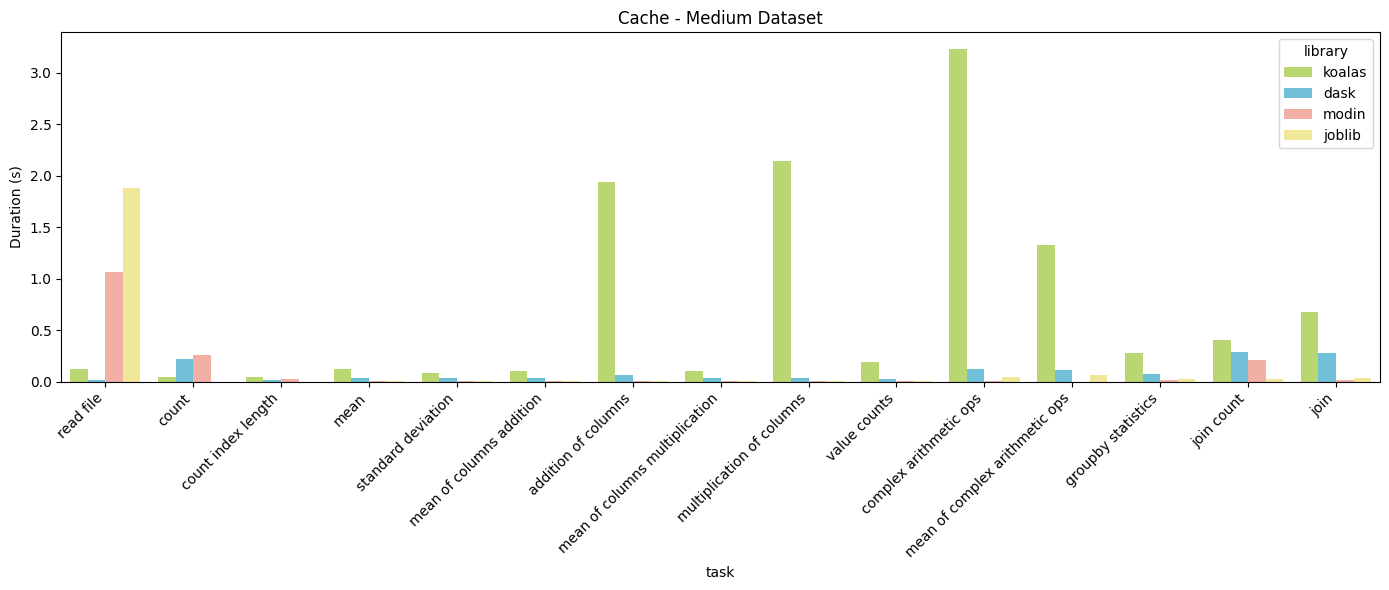

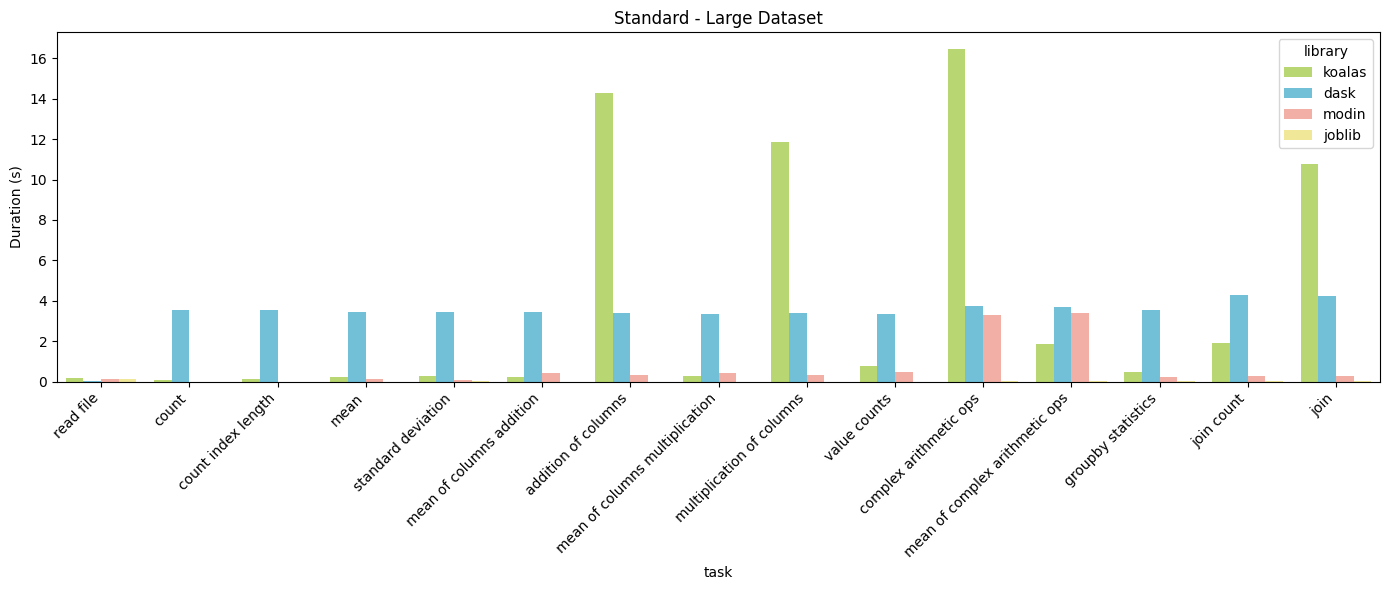

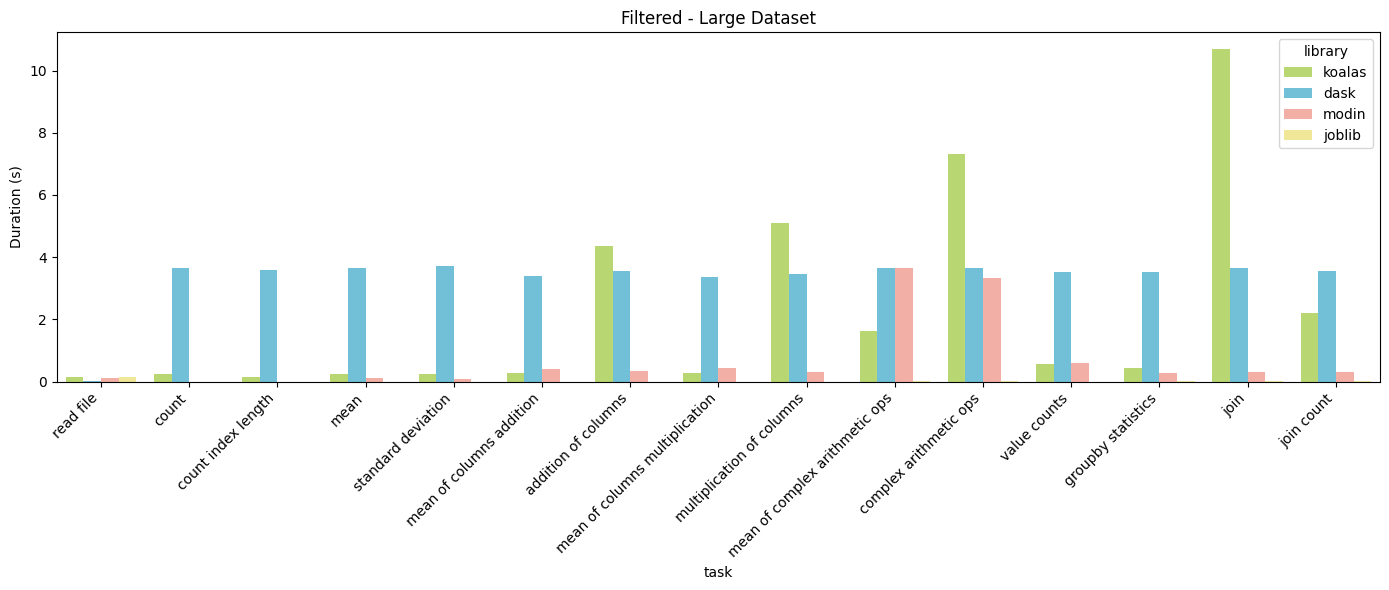

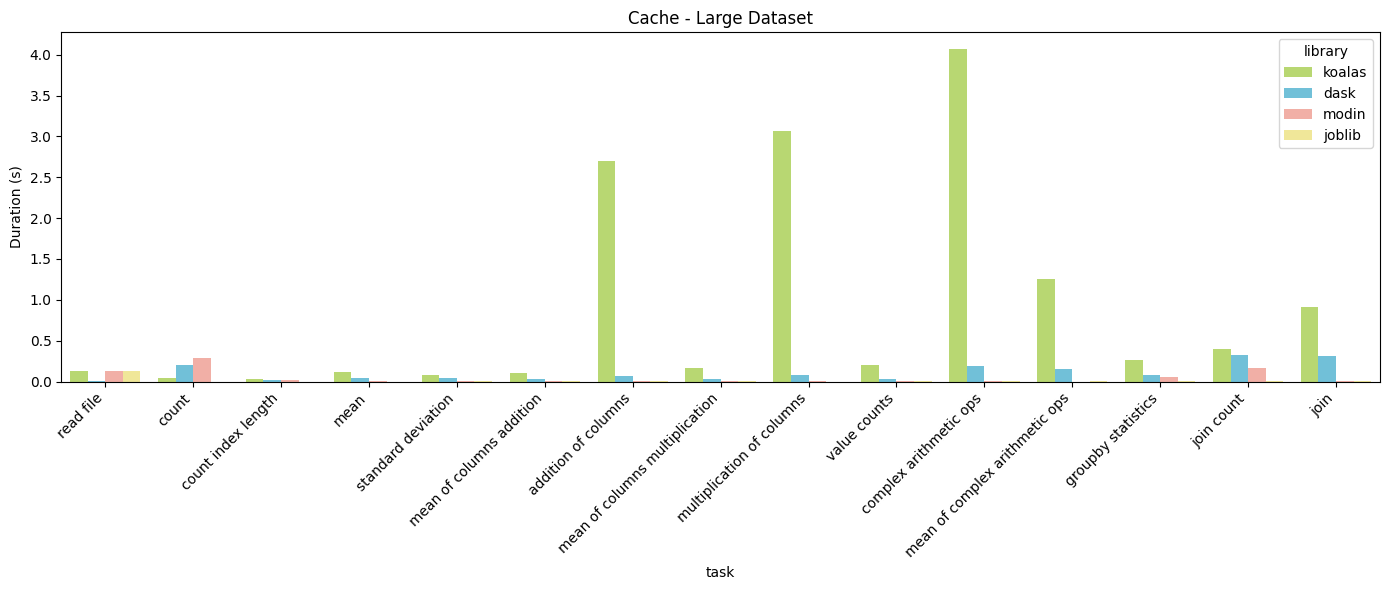

In [ ]:
cc= ["#BEE861",   "#60C9E9", "#FEA699",  "#FFF38A"]

for size in sizes:
    for variant in variants:
        plt.figure(figsize=(14, 6))
        sns.barplot(
            data=df_all[(df_all['size'] == size) & (df_all['variant'] == variant)],
            x='task',
            y='duration',
            hue='library',
            palette=cc
        )
        plt.title(f'{variant.capitalize()} - {size.capitalize()} Dataset')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Duration (s)')
        plt.tight_layout()
        plt.show()

# **Standard Small Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **complex arithmetic ops and mean of columns**
    - **join and join count**

    **Justification:** Koalas is based on Spark, which introduces a high orchestration overhead—even for simple operations. With small datasets, this coordination cost becomes disproportionately large compared to the actual computation time.

- Modin

    - **complex arithmetic ops and mean of complex arithmetic ops**

    **Justification:** Modin attempts to parallelize operations, including complex ones. However, for small datasets, the overhead of managing threads or distributed processes outweighs any performance gain.


**Best Execution Times (Exceptionally Low)**

- Joblib

    - **complex arithmetic ops and mean of complex arithmetic ops**

    **Justification:** Joblib runs code directly on the CPU with minimal overhead. In pure numerical tasks (without heavy data structure manipulation), it delivers superior performance.

- Modin

    - **join, join count, multiplication of columns**

    **Justification:** Modin performs well on pandas-like operations. In simple joins and column operations, the small size of the dataset makes the lightweight parallelism effective.

# **Filtered Small Dataset**

**Worst Execution Times (Excessively High)**

- Modin

    - **complex arithmetic ops and mean of columns**

    **Justification:** Modin attempts to parallelize pandas operations automatically, but this coordination overhead becomes counterproductive on small datasets. When performing multi-column numerical computations, the latency introduced by initializing multiple processes or threads outweighs any computational benefits at this scale.


**Best Execution Times (Exceptionally Low)**

- Joblib

    - **complex arithmetic ops, mean of complex arithmetic ops, joins, and reductions**

    **Justification:** Joblib executes numerical operations directly on the CPU with minimal overhead, making it ideal for small, filtered datasets where parallelism is unnecessary. Since the Kit dataset is already filtered and well-structured, operations are performed efficiently in memory without the need for complex data handling or orchestration.

# **Cache Small Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **complex arithmetic ops, mean of complex arithmetic ops and addition of columns**

    **Justification:** Koalas, built on top of Apache Spark, incurs a significant orchestration cost even for basic operations. In this small dataset, complex arithmetic and column-wise operations trigger unnecessary Spark jobs and data shuffling, which drastically increases execution time compared to in-memory libraries. The reactive Spark backend introduces delays that are disproportionate to the dataset size.

- Modin & Joblib
   - **file read operations**

    **Justification:** Both Modin and Joblib show higher execution times for file I/O tasks. In the case of Modin, reading a file involves launching and coordinating multiple workers, which adds latency for small datasets. Joblib, while efficient for in-memory computations, is not optimized for file I/O leading to slower initial loading times.


**Best Execution Times (Exceptionally Low)**

- Most Libraries (Dask, Modin, Joblib)

    - **almost all operations**

    **Justification:**  Due to the small and already cached nature of the dataset, most operations complete extremely quickly across all libraries. Once loaded into memory, operations like joins, reductions, and basic arithmetic require minimal computation. The simplicity of the dataset and the absence of I/O bottlenecks allow all libraries to achieve near-optimal performance.

# **Standard Medium Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **addition of columns, multiplication of columns, complex arithmetic ops, and join**

    **Justification:** Koalas suffers from Spark’s distributed execution overhead, which becomes increasingly inefficient when handling medium-sized datasets that still fit comfortably in memory. Operations like arithmetic and joins trigger Spark’s job scheduling, task serialization, and communication between workers—introducing significant delays compared to in-memory alternatives.


**Best Execution Times (Exceptionally Low)**

- Joblib

    - **addition of columns, multiplication of columns, complex arithmetic ops, and join**

    **Justification:**  Joblib excels in medium-sized datasets where the entire computation can be handled within the system’s memory without parallelization overhead. By executing directly on the CPU, Joblib delivers fast results for numerical and join operations, benefiting from low-level optimizations and minimal orchestration delays.

# **Filtered Medium Dataset**

**Worst Execution Times (Excessively High)**

- Koalas & Modin

    - **join, complex arithmetic ops, and mean of complex arithmetic ops**

    **Justification:** Both Koalas and Modin introduce overhead from distributed or parallel execution frameworks (Spark for Koalas, Ray/Dask for Modin). In a medium but already filtered dataset, these operations—especially joins and column-wise aggregations—trigger coordination costs and memory handling inefficiencies that outweigh their computational benefits at this scale.

- Joblib

    - **file read operations**

    **Justification:** While Joblib is optimized for in-memory processing, its file I/O performance lags behind libraries like pandas. Reading files with Joblib introduces unnecessary serialization overhead and lacks the streamlined I/O optimizations present in more specialized data-handling libraries.

**Best Execution Times (Exceptionally Low)**

- Joblib

    - **mean, count, and other basic aggregations**

    **Justification:**  For medium-sized datasets already loaded into memory, Joblib is highly efficient at performing statistical and reduction operations. Its direct execution on the CPU, combined with minimal overhead, makes it particularly suitable for column-wise operations such as computing means and counts on structured, filtered data.



# **Cache Medium Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **complex arithmetic ops, mean of complex arithmetic ops, and addition of columns**

    **Justification:** Even with a medium-sized dataset already cached, Koalas continues to suffer from Spark’s orchestration overhead. Operations like complex arithmetic and column additions trigger Spark execution plans, job scheduling, and task distribution, which result in execution times far higher than necessary for in-memory data of this scale.

- Modin & Joblib

    - **file read operations**

    **Justification:** Despite being effective in memory, both Modin and Joblib perform poorly when reading files. Modin’s initialization of parallel workers for I/O adds overhead that doesn't scale well with moderately sized cached datasets. Joblib, not being a specialized I/O tool, shows slower performance during data loading due to its lack of native file read optimizations.

**Best Execution Times (Exceptionally Low)**

- Most Libraries (Dask, Modin, Joblib)

    - **almost all operations**

    **Justification:**  With the dataset already cached and residing in memory, most operations—such as joins, arithmetic, and aggregations—execute rapidly across all major libraries. The medium size offers enough data to benefit from optimized execution paths while avoiding memory or orchestration bottlenecks, resulting in consistently low execution times.

# **Standard Large Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **addition of columns, multiplication of columns, join, and complex arithmetic ops**

    **Justification:**  Koalas' dependency on Spark becomes a critical bottleneck at large scale when the operations remain relatively simple. Even though the dataset size justifies distributed processing in theory, Spark’s orchestration layers (job scheduling, task distribution, and data shuffling) dominate execution time for standard operations. This makes Koalas inefficient for numerical and relational tasks that other libraries handle more gracefully in memory.

- Dask

    - **general performance stagnation across operations**

    **Justification:**  Dask showed nearly constant execution times across operations, regardless of complexity. This consistency likely stems from overhead in task scheduling, serialization, or chunk management. As a result, operations that should have scaled better—like arithmetic or joins—did not benefit from data size increases. Fixed per-task costs may be flattening performance, especially when tasks are too small to offset the orchestration overhead.

**Best Execution Times (Exceptionally Low)**

- Joblib
    - **almost all operations (addition, multiplication, joins, and complex arithmetic ops)**

    **Justification:**   Joblib maintains exceptional performance even at large dataset sizes, especially when the entire dataset can be processed in memory. Its CPU-bound execution avoids the coordination costs of distributed frameworks. For operations involving numerical computation and joins, Joblib leverages efficient memory access and minimal runtime overhead, making it the top performer in this scenario.

# **Filtered Large Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **join and complex arithmetic operations**

    **Justification:**  Even when working with filtered data, Koalas continues to suffer from Spark's inherent orchestration overhead. Joins and complex arithmetic operations require launching Spark jobs, managing distributed execution, and potentially shuffling data across partitions. These steps introduce significant delays that are disproportionate given the reduced size from filtering, making Koalas particularly inefficient for these tasks.


- Dask

    - **general performance degradation across most operations**

    **Justification:** Dask continues to have a worse performance for the large datatset, even after filtering. The complexity of managing delayed execution, partitioning, and task scheduling adds overhead that is not offset by performance gains at this scale. For a large but filtered dataset, Dask’s architecture introduces more coordination cost than benefit, especially when compared to streamlined in-memory processing alternatives.

**Best Execution Times (Exceptionally Low)**

- Joblib
    - **almost all operations (addition, multiplication, joins, and complex arithmetic ops)**

    **Justification:**   Joblib demonstrates consistent efficiency by executing operations directly in memory with minimal overhead. In the filtered large dataset, this approach remains highly effective—avoiding the bottlenecks associated with distributed coordination. For both numerical operations and joins, Joblib's low-level optimizations and single-process execution yield excellent performance across the board.

# **Cache Large Dataset**

**Worst Execution Times (Excessively High)**

- Koalas

    - **complex arithmetic operations and joins**

    **Justification:**   Despite the performance gains observed in other libraries due to caching, Koalas remains significantly slower. This is primarily due to its Spark-based backend, which still incurs orchestration overhead even when the data is already loaded in memory. Spark initiates job planning, shuffling, and task execution pipelines that dominate execution time for operations like joins and complex arithmetic, making Koalas consistently the slowest option.

**Best Execution Times (Exceptionally Low)**

- Most Libraries (Dask, Modin, Joblib)

    - **majority of operations (joins, arithmetic, aggregations, file reads)**

    **Justification:** Once the dataset is cached, all major libraries—except Koalas—see substantial performance improvements. Operations that previously incurred I/O delays or initialization overhead now execute almost instantly, as the data is already memory-resident. Joblib, in particular, continues to deliver top-tier performance due to its efficient in-memory computation model, while Dask and Modin also benefit from reduced coordination time. The result is near-optimal execution across almost all operations.

**Conclusion: Performance Comparison by Dataset Size and Type**

The performance of each library varies significantly depending on the dataset size and operation type:

- Standard Datasets (unfiltered, with I/O):

 - Koalas consistently performs poorly due to Spark’s orchestration overhead, especially in joins and arithmetic operations.

 - Dask shows mixed results—efficient in large-scale distributed scenarios, but with visible overhead in standard-sized tasks.

 - Joblib consistently outperforms others in most in-memory numerical and aggregation tasks.

 - Modin offers good performance in pandas-like operations but suffers during I/O and complex parallel tasks.

- Filtered Datasets (reduced data size, still involves I/O):

 - Koalas remains inefficient—its orchestration cost is not offset by the smaller dataset.

 - Dask often underperforms due to the coordination cost outweighing benefits at reduced scale.

 - Joblib handles the reduced data very well, with fast execution in nearly all operations.

 - Modin improves slightly but still shows inefficiencies in more complex or I/O-bound operations.

- Cached Datasets (entirely in memory, I/O eliminated):

 - Performance improves significantly across all libraries, with minimal execution time for most operations.

 - Koalas continues to underperform, as Spark’s job scheduling and lazy evaluation are still triggered even with data in memory.

 - Joblib excels in all scenarios, providing low-latency computation regardless of dataset size or type.

 - Dask and Modin benefit from caching, with overhead drastically reduced, leading to highly competitive performance.




**Stacked Execution Time per Library and Dataset Size**

Each chart generated shows a stacked bar chart, where:

- Each bar corresponds to a specific library-size combination (e.g., Koalas (small), Joblib (large)).

- The height of each bar represents the total execution time (in seconds) for all tasks combined.

- Each segment within the bar corresponds to a specific task (e.g., join, mean, complex ops, etc.), and shows how much time that task contributed to the total.

- The use of custom colors improves readability and helps distinguish between tasks.

- The variant in the title (e.g., standard, filtered, cached) indicates the data preparation context used in the benchmark.



In [ ]:
custom_colors = ["#9B85B8", "#526194",  "#214A68", "#2C8C7A",  "#3B8C75",
                "#83BEB1",  "#A5D49C",  "#D9E2AC",  "#F39B78", "#E07A5F",
                "#CE6C6B",  "#BD4B77",  "#A06A9C",  "#8F2F77", "#5B1E4F",
                ]

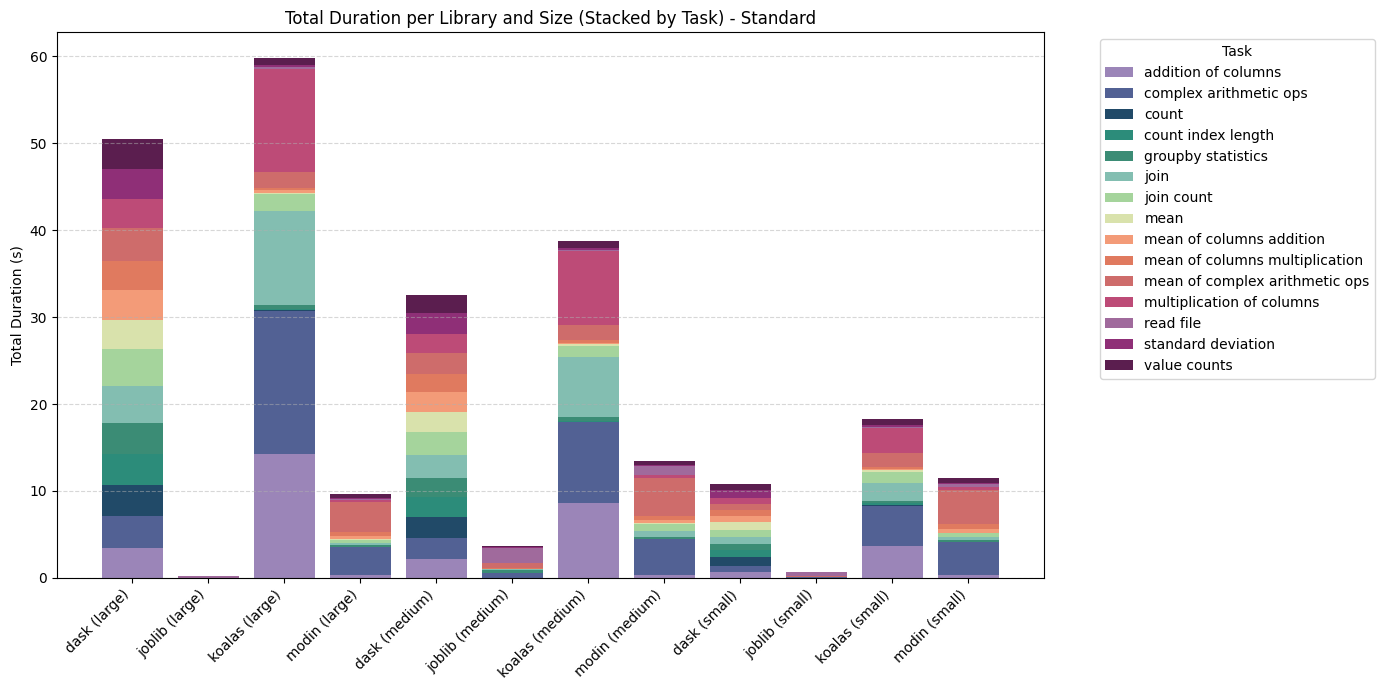

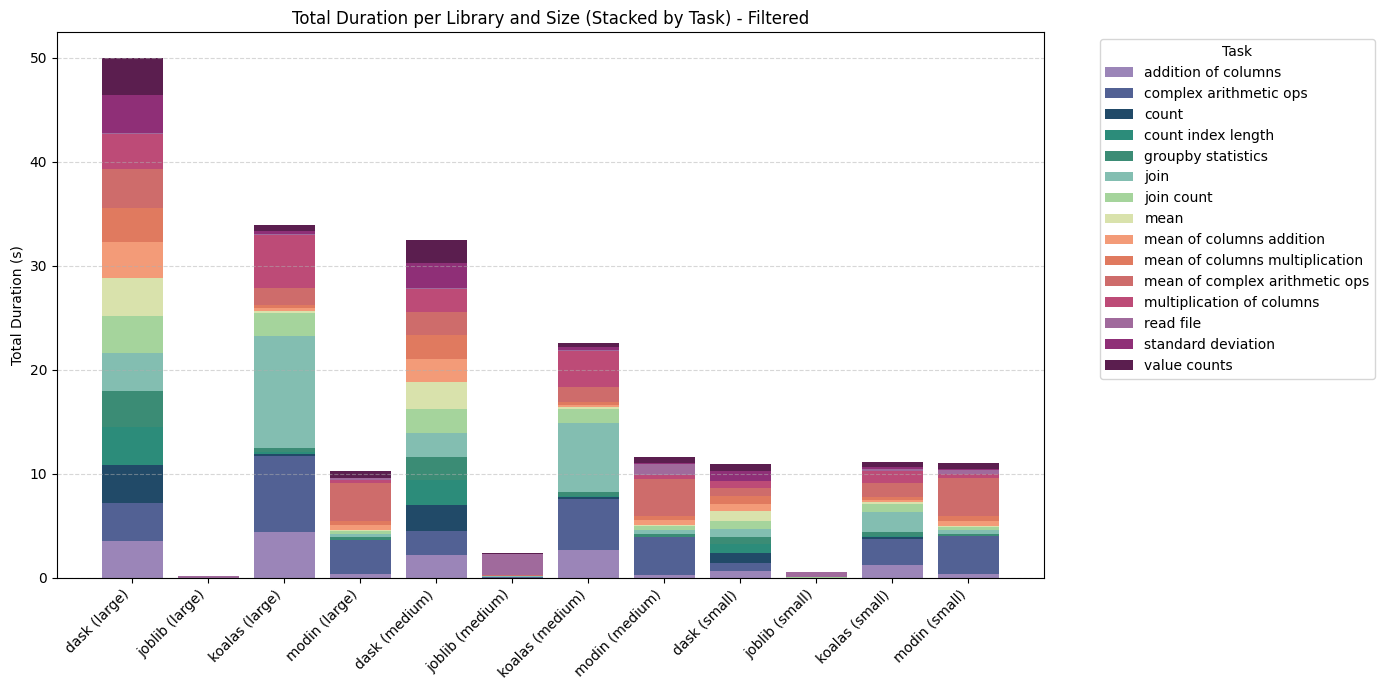

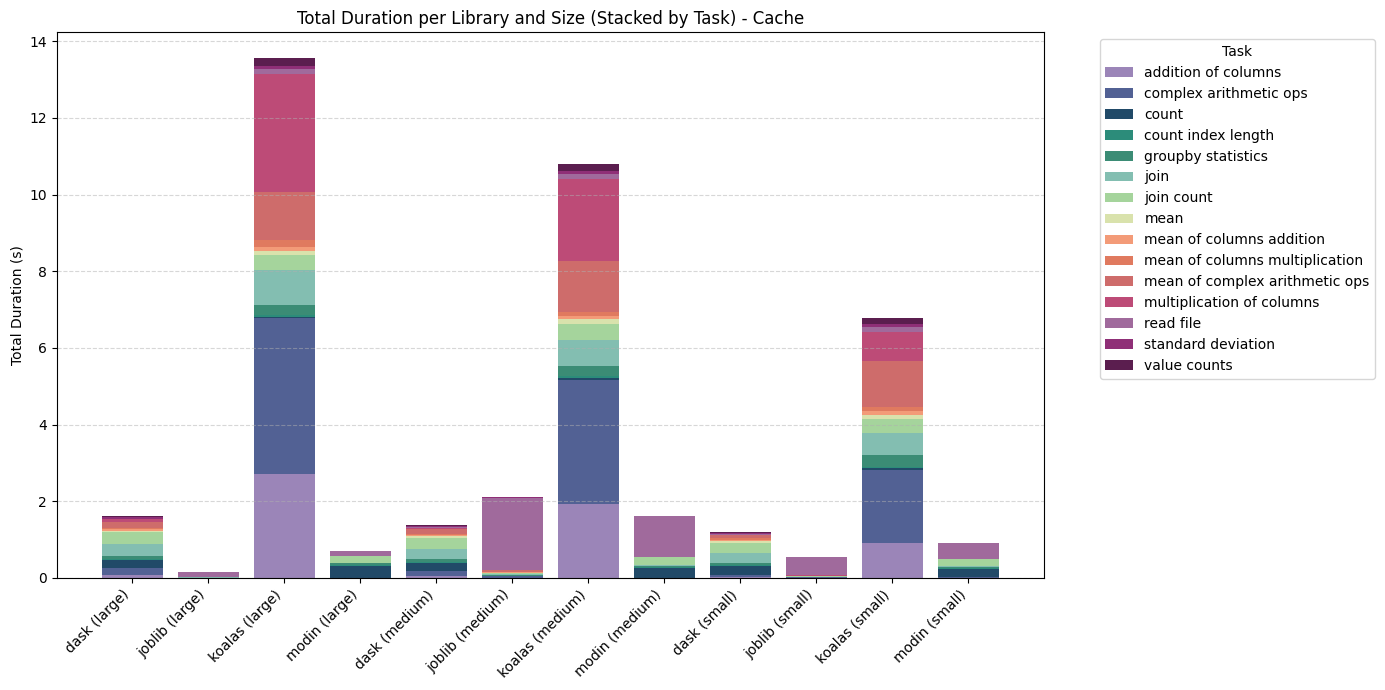

In [ ]:
for variant in variants:
    df_variant = df_all[df_all['variant'] == variant]

    pivot = (
        df_variant.groupby(['library', 'size', 'task'])['duration']
        .sum()
        .reset_index()
        .pivot_table(index=['library', 'size'], columns='task', values='duration', fill_value=0)
    )

    pivot = pivot.reset_index()
    pivot['label'] = pivot.apply(lambda x: f"{x['library']} ({x['size']})", axis=1)
    pivot = pivot.sort_values(['size', 'library'])

    plt.figure(figsize=(14, 7))
    bottom = np.zeros(len(pivot))
    for i, col in enumerate(pivot.columns[2:-1]):
        plt.bar(pivot['label'], pivot[col], bottom=bottom, label=col, color=custom_colors[i])
        bottom += pivot[col].values

    plt.title(f'Total Duration per Library and Size (Stacked by Task) - {variant.capitalize()}')
    plt.ylabel('Total Duration (s)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Analysis**

The tallest bars consistently belong to Koalas, especially for the large dataset, indicating that Koalas exhibits the longest total execution times in these scenarios. This is likely due to the substantial orchestration and scheduling overhead inherent to Spark, which Koalas relies on. These overheads become more pronounced as dataset size increases, causing poor scalability and slower performance.

Conversely, Joblib shows the shortest bars for the large dataset, reflecting its efficiency in handling large in-memory computations with minimal overhead. Joblib’s lightweight execution model allows it to process tasks quickly, making it the best performer on large datasets.

When analyzing the filtered dataset, we observe that Dask’s bars become the tallest, while execution times for other libraries notably decrease. This suggests that Dask’s overhead and task management complexity outweigh its benefits at this filtered scale. The smaller dataset size reduces the parallelism advantage Dask usually offers, leading to longer total durations compared to other libraries optimized for smaller workloads.

Finally, for the cached dataset, Koalas again shows the tallest bars across all dataset sizes (small, medium, large), indicating persistent performance issues even when data is fully loaded into memory. This is consistent with Koalas’ dependency on Spark’s execution model, which introduces latency regardless of caching. Meanwhile, other libraries show much smaller bars, demonstrating significant performance improvements due to the elimination of I/O overhead and faster in-memory processing.


**Total Duration per Library**

This graphic is a stacked bar chart representing the total execution time spent by different libraries on various tasks for a specific combination of dataset variant and size.

For each library, the total duration of each individual task is stacked on top of one another, showing their contribution to the overall execution time.

- The x-axis lists the libraries, such as Koalas, Dask, Modin, Joblib.

- The y-axis shows the total execution time in seconds.

- Each color segment within a bar corresponds to a different task, allowing you to see which tasks dominate the runtime for each library.

- Separate plots are generated for each pair of variant (e.g., standard, filtered, cached) and dataset size (small, medium, large), enabling detailed comparison across these dimensions.

This visualization helps identify which libraries perform better or worse for particular dataset conditions and which tasks are the main contributors to their runtime.

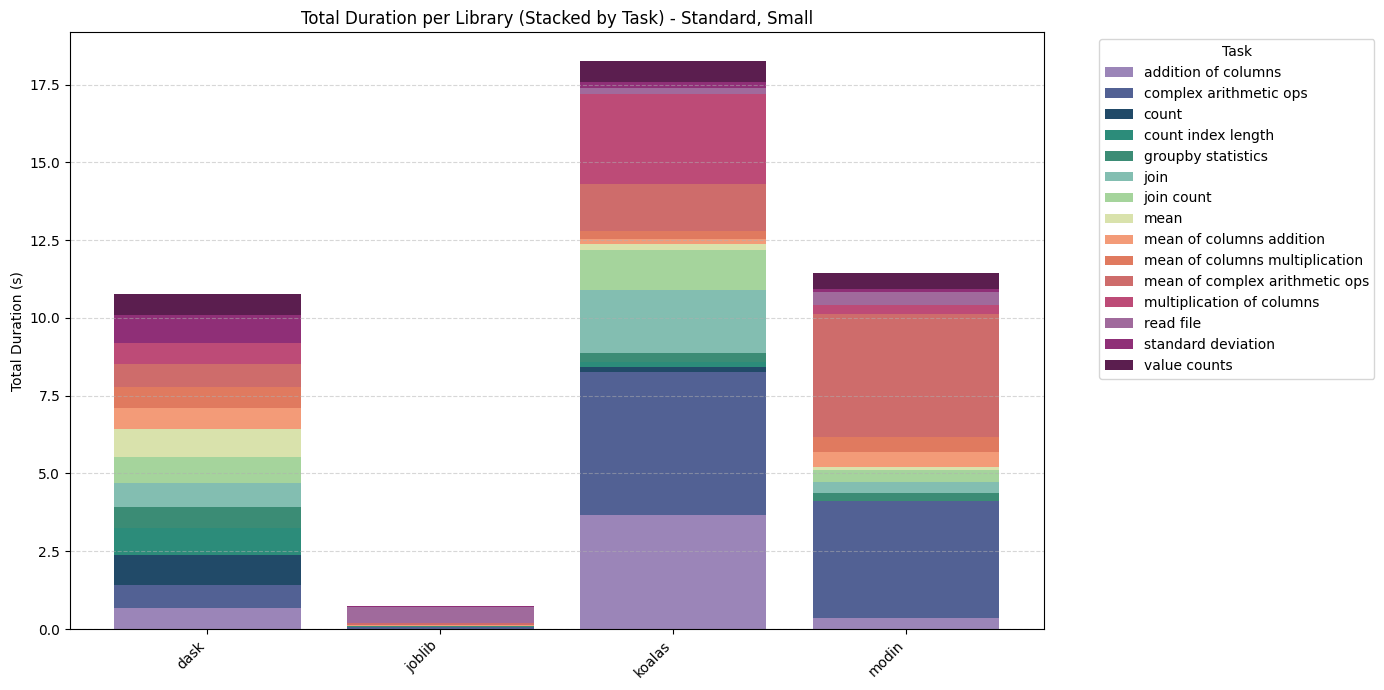

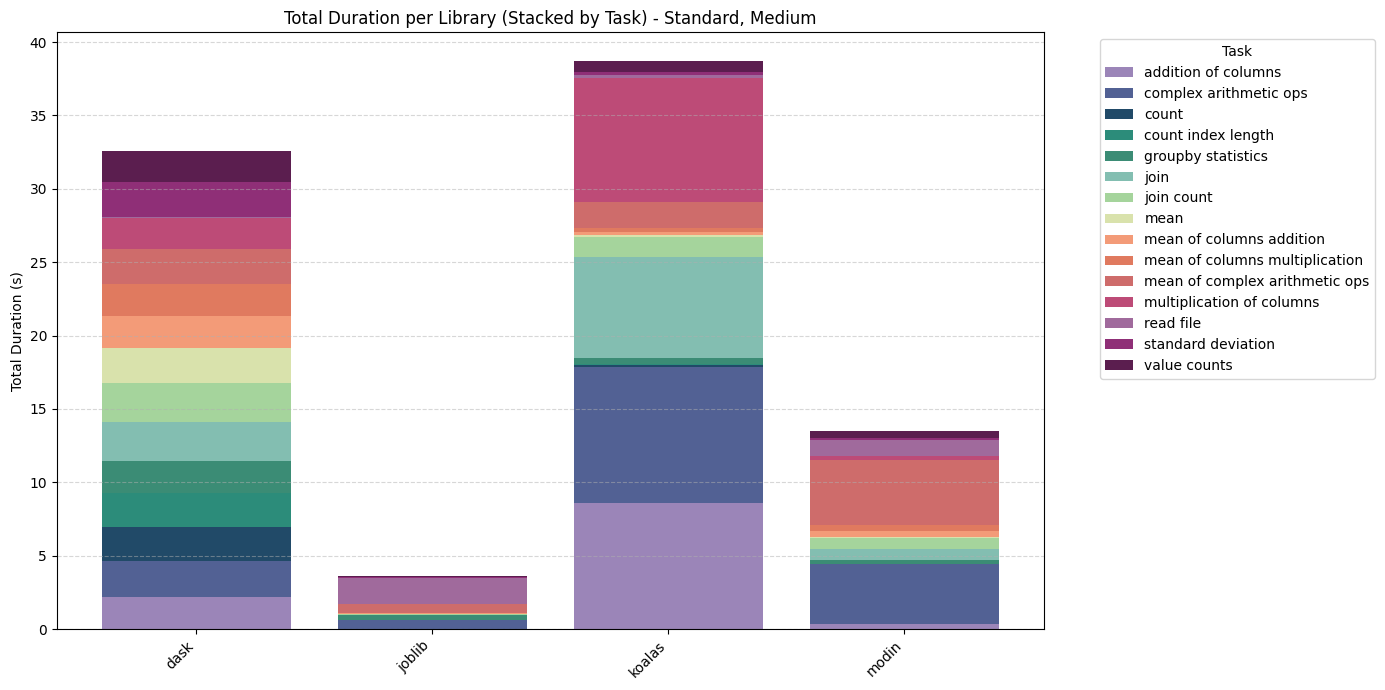

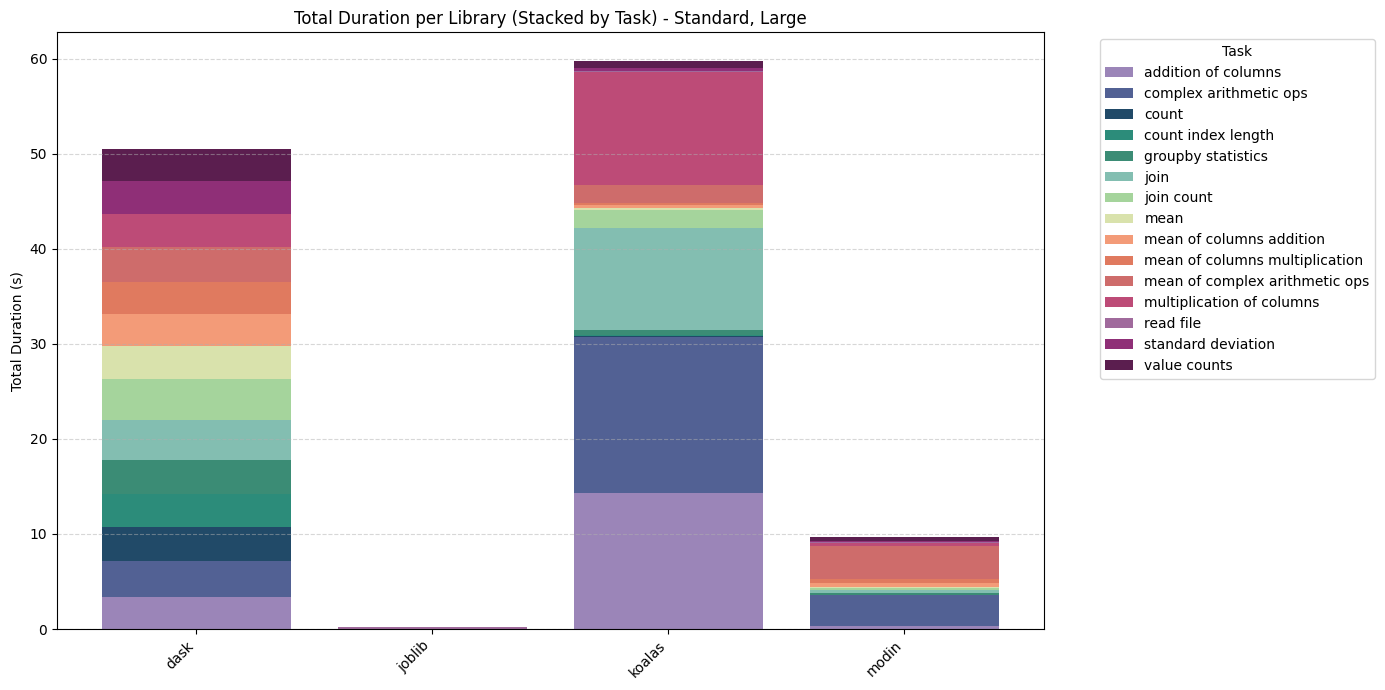

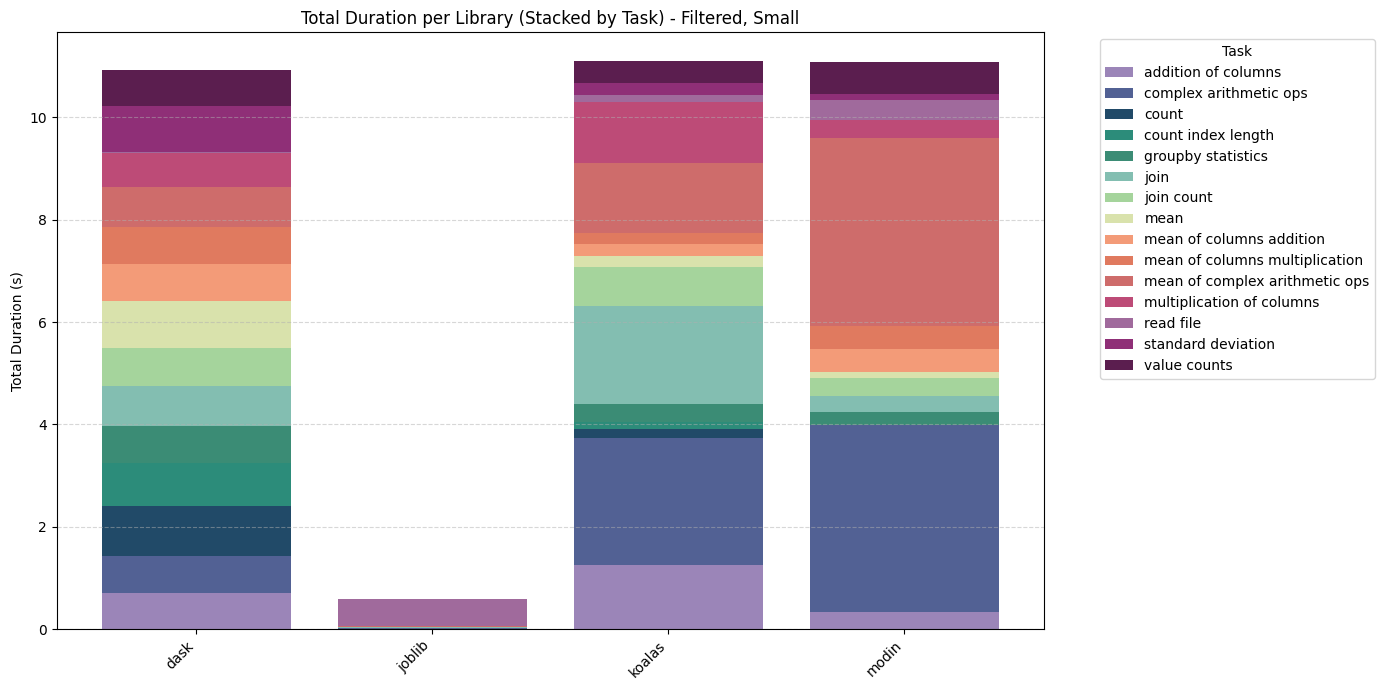

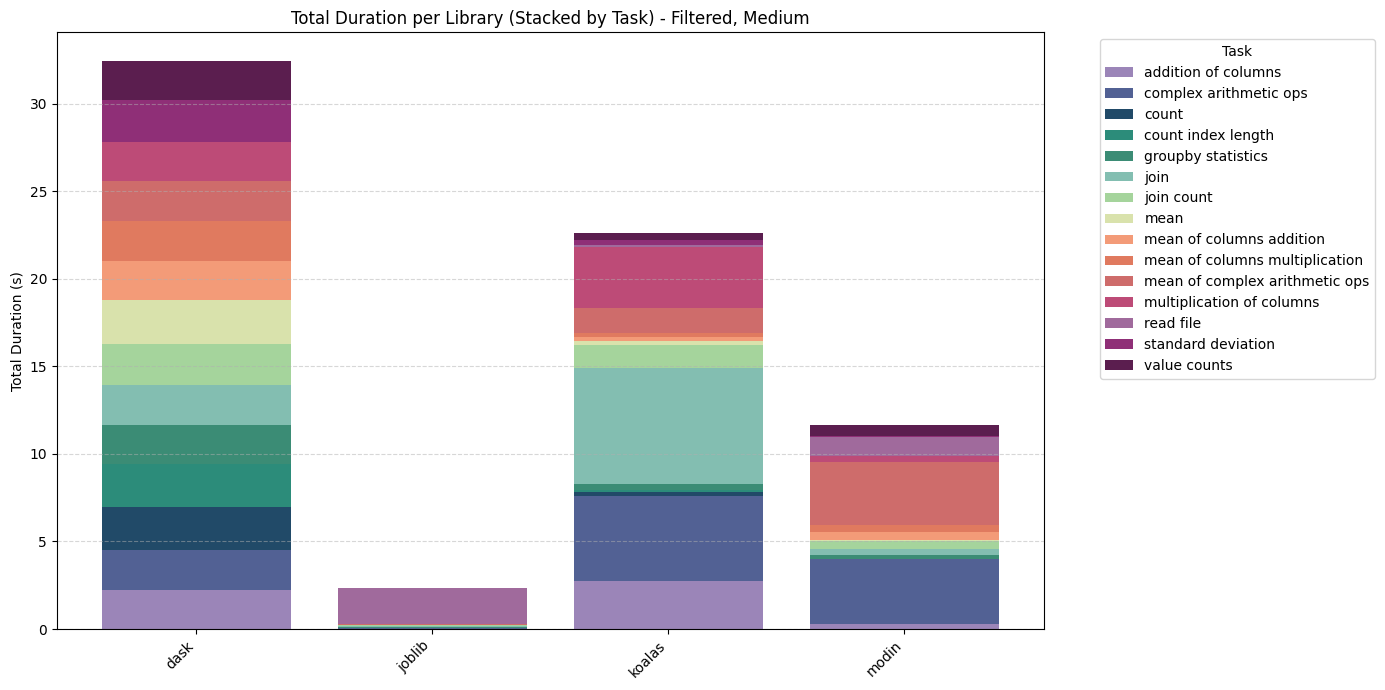

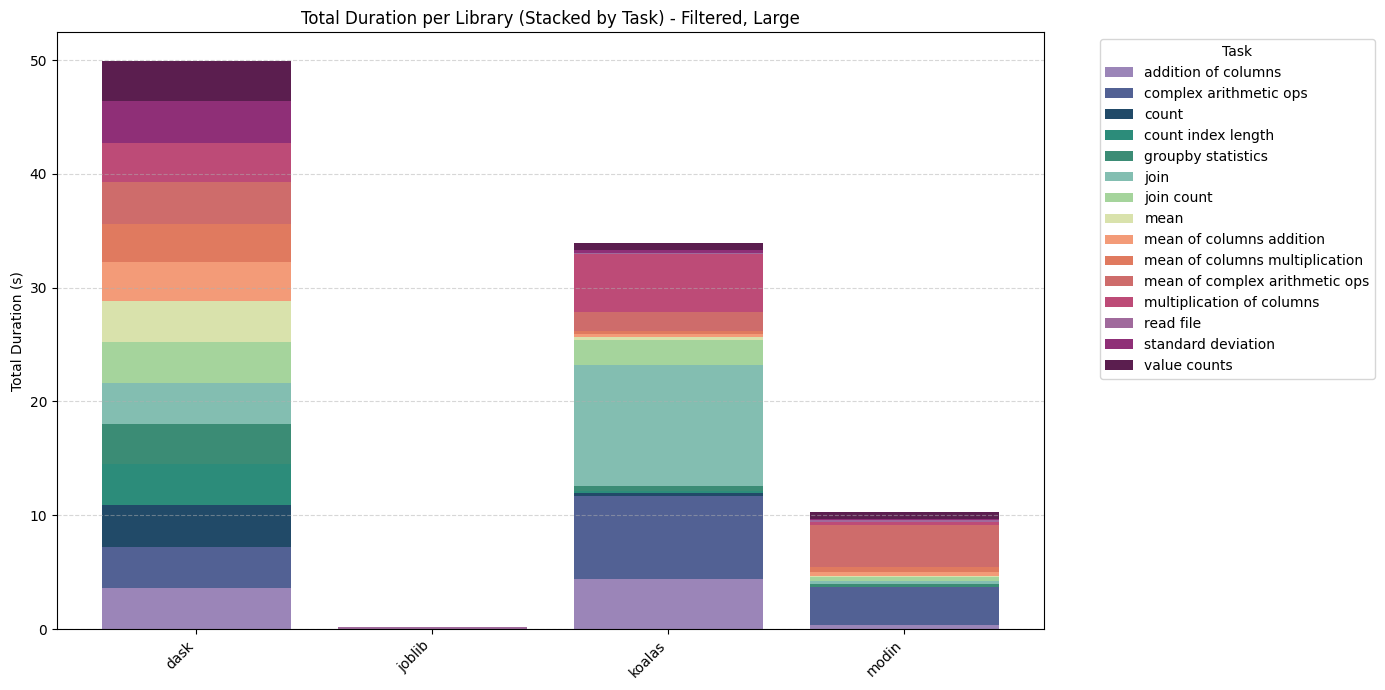

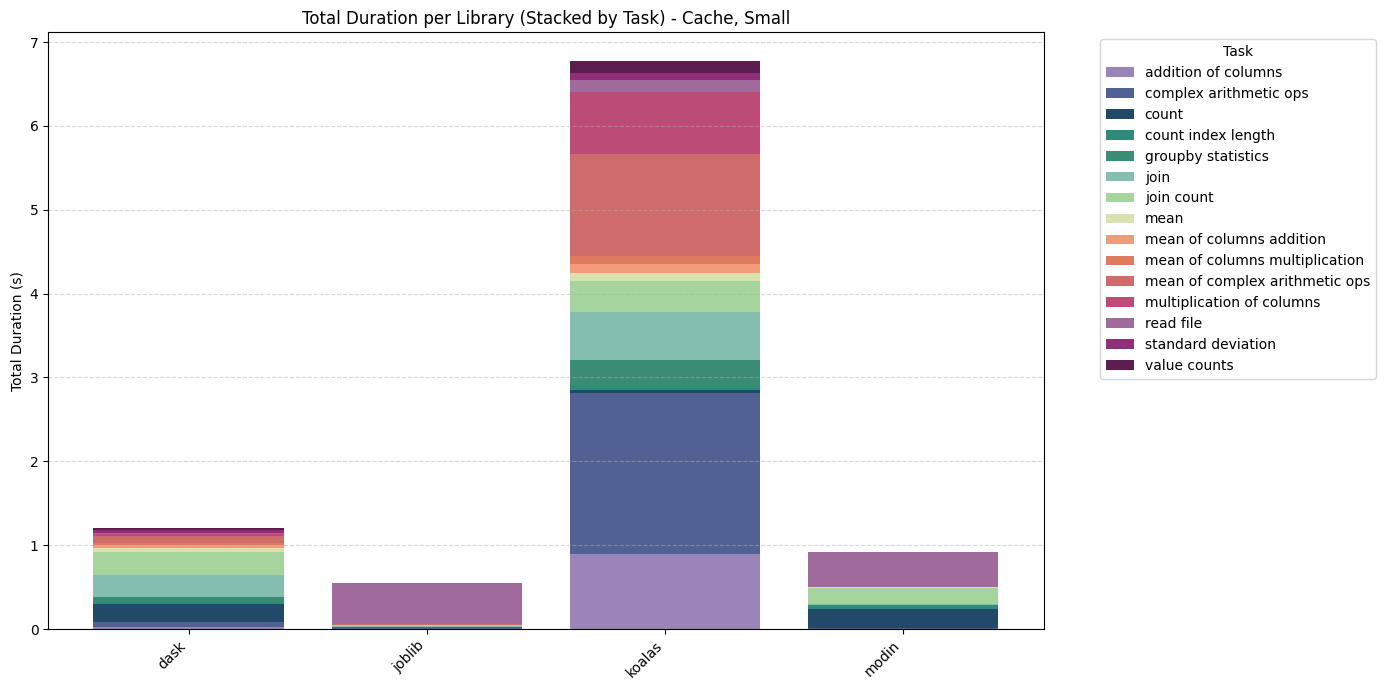

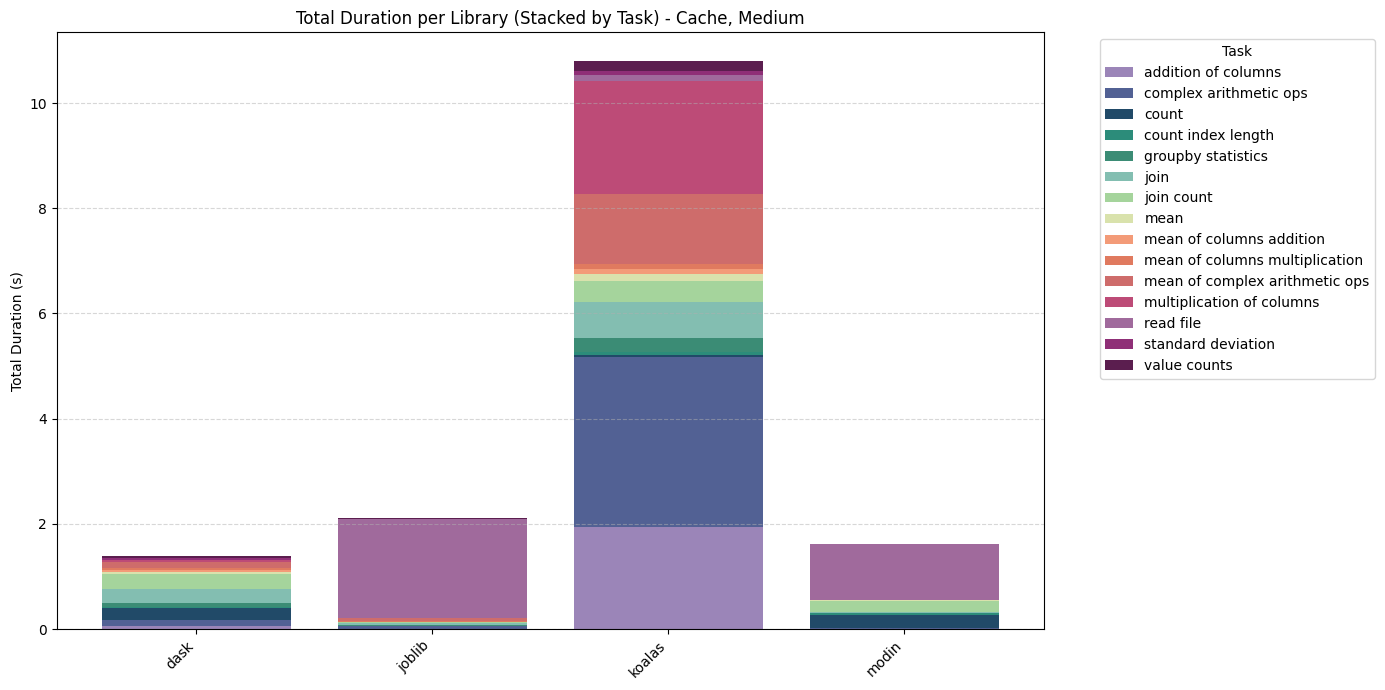

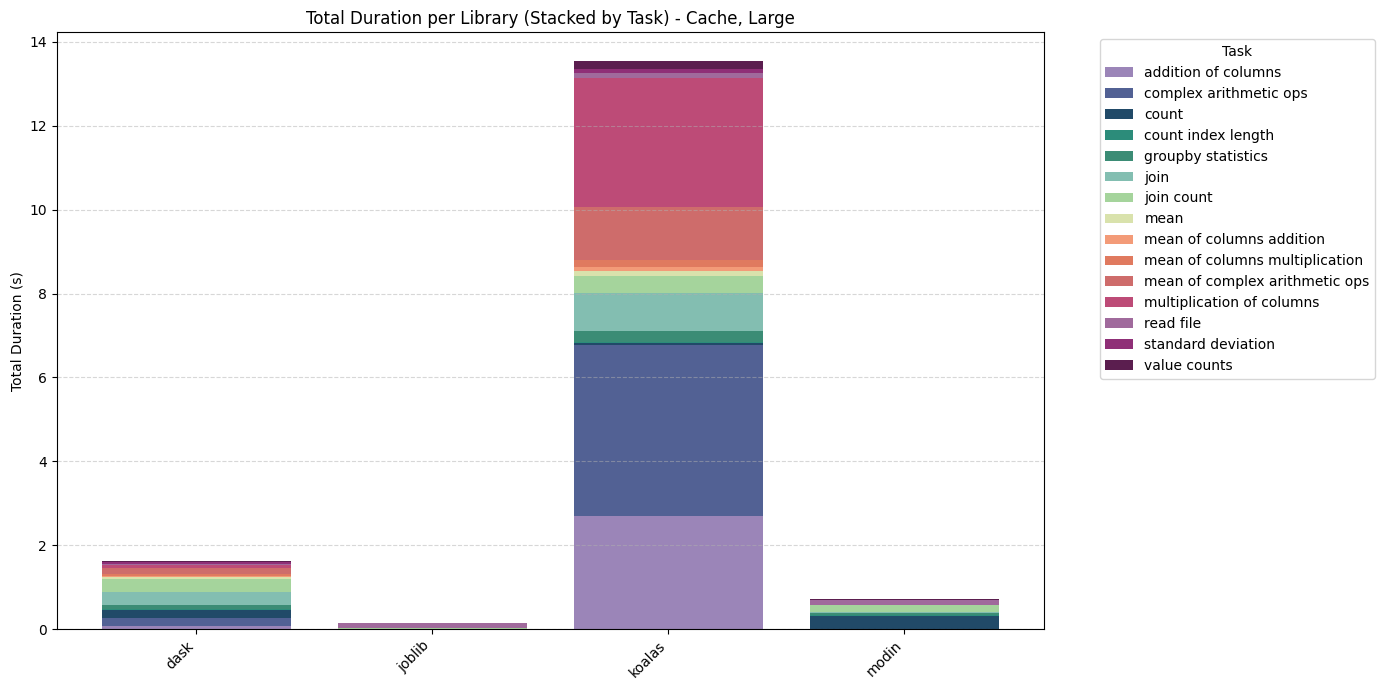

In [ ]:
for variant in variants:
    for size in sizes:
        df_variant_size = df_all[(df_all['variant'] == variant) & (df_all['size'] == size)]

        pivot = (
            df_variant_size.groupby(['library', 'task'])['duration']
            .sum()
            .reset_index()
            .pivot_table(index='library', columns='task', values='duration', fill_value=0)
        )

        pivot = pivot.reset_index()
        pivot = pivot.sort_values('library')

        plt.figure(figsize=(14, 7))
        bottom = np.zeros(len(pivot))
        for i, col in enumerate(pivot.columns[1:]):  # skip 'library'
            plt.bar(pivot['library'], pivot[col], bottom=bottom, label=col, color=custom_colors[i % len(custom_colors)])
            bottom += pivot[col].values

        plt.title(f'Total Duration per Library (Stacked by Task) - {variant.capitalize()}, {size.capitalize()}')
        plt.ylabel('Total Duration (s)')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

**Analysis**

For the small and medium datasets, the libraries with the highest execution times vary depending on the dataset variant:

- In the standard small dataset and standard medium dataset, Koalas consistently shows the highest bars, reflecting its significant overhead due to Spark orchestration, which is noticeable even at smaller scales.

- In the filtered small dataset, the highest bars appear for Koalas, Dask, and Modin. This suggests that these libraries incur greater overhead when managing distributed or parallel execution on filtered data, where the dataset size and complexity do not justify their heavier coordination.

- For the filtered medium dataset, Dask bars become dominant, highlighting that Dask struggles with performance on filtered datasets of moderate to large size, likely due to task scheduling overhead and inefficient parallelization on these specific workloads.

- In the cached medium and cached large datasets, Koalas again shows the highest bars. This indicates that even with cached data—which removes input/output bottlenecks—Koalas’s Spark-based backend introduces latency that negatively impacts total execution time compared to other libraries.

**Justification:**
The trend shows that Koalas tends to have the largest execution time overhead across most dataset sizes and variants because Spark's job scheduling and orchestration costs remain significant regardless of caching or filtering. Dask, while designed for parallelism, shows performance degradation on filtered datasets, likely due to task management overhead that is not compensated by parallel speedup at those scales. Modin also experiences overhead on filtered datasets, but to a lesser extent than Dask or Koalas. On the other hand, libraries like Joblib maintain relatively low execution times, as they operate with minimal overhead and favor in-memory computations.

**Rapids comparison**

In [ ]:
data_map_rapids = {
    'rapids': {
        'small': {
            'standard': pd.read_parquet("Dask_Rapids/Results/rapids_local_small"),
            'filtered': pd.read_parquet("Dask_Rapids/Results/rapids_filtered_local_small"),
            'cache': pd.read_parquet("Dask_Rapids/Results/rapids_cache_local_small"),
        },
        'medium': {
            'standard': pd.read_parquet("Dask_Rapids/Results_M/rapids_local_medium"),
            'filtered': pd.read_parquet("Dask_Rapids/Results_M/rapids_filtered_local_medium"),
            'cache': pd.read_parquet("Dask_Rapids/Results_M/rapids_cache_local_medium"),
        },
        'large': {
            'standard': pd.read_parquet("Dask_Rapids/Results_L/rapids_local_large"),
            'filtered': pd.read_parquet("Dask_Rapids/Results_L/rapids_filtered_local_large"),
            'cache': pd.read_parquet("Dask_Rapids/Results_L/rapids_cache_local_large"),
        }
    }
}

In [ ]:
dfs = []
for size, variants in data_map_rapids['rapids'].items():
    for variant, df in variants.items():
        for _, row in df.iterrows():
            dfs.append({
                'library': 'rapids',
                'size': size,
                'variant': variant,
                'task': row['task'],
                'duration': row['duration']
            })

df_rapids = pd.DataFrame(dfs)


In [ ]:
df_rapids

,library,size,variant,task,duration
0,rapids,small,standard,read file,0.053158
1,rapids,small,standard,count,0.087718
2,rapids,small,standard,count index length,0.215881
3,rapids,small,standard,mean,0.009201
4,rapids,small,standard,standard deviation,0.030684
...,...,...,...,...,...
130,rapids,large,cache,complex arithmetic ops,0.162844
131,rapids,large,cache,mean of complex arithmetic ops,0.002048
132,rapids,large,cache,groupby statistics,0.035207
133,rapids,large,cache,join count,0.233179


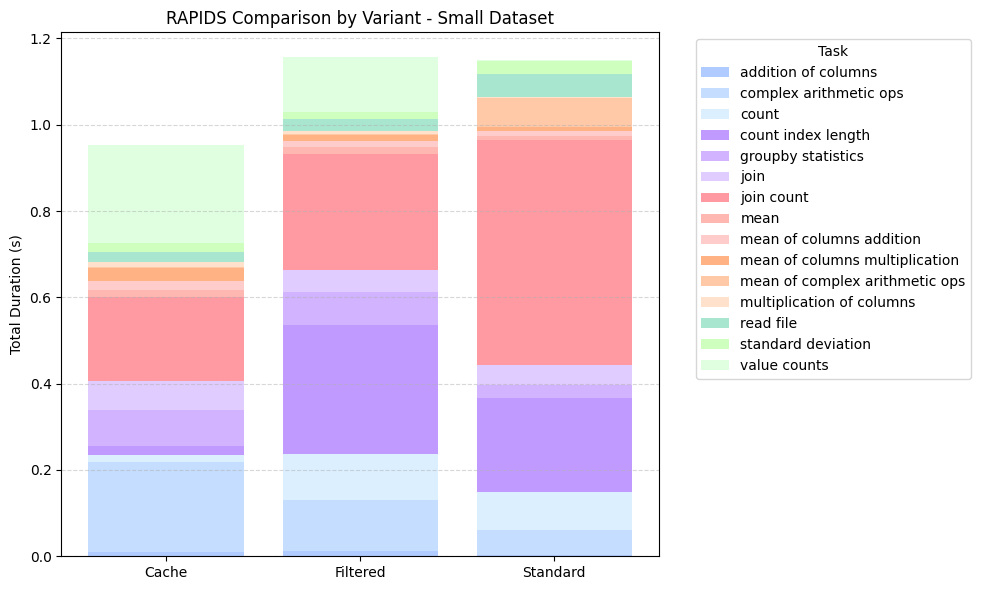

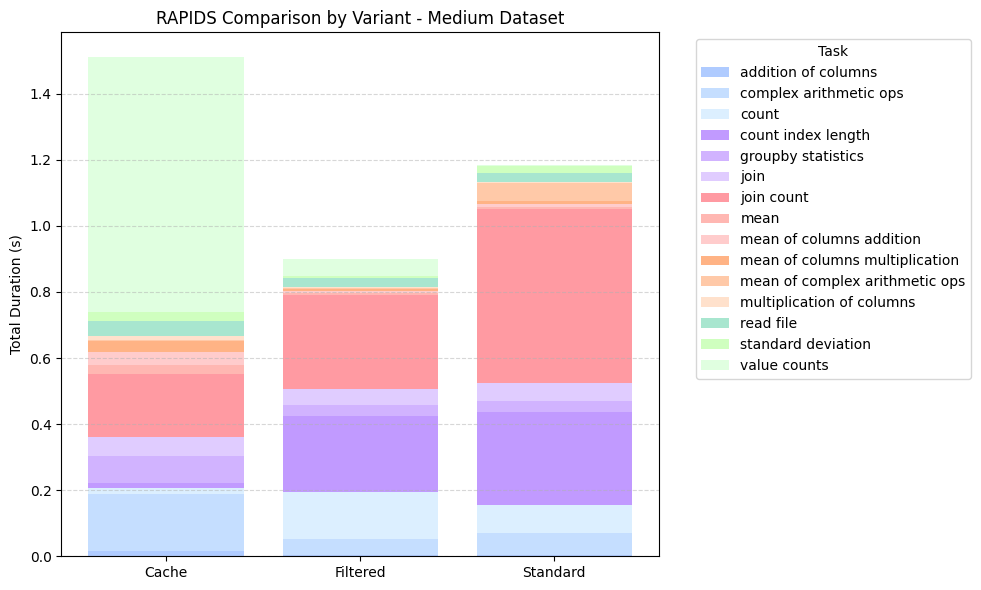

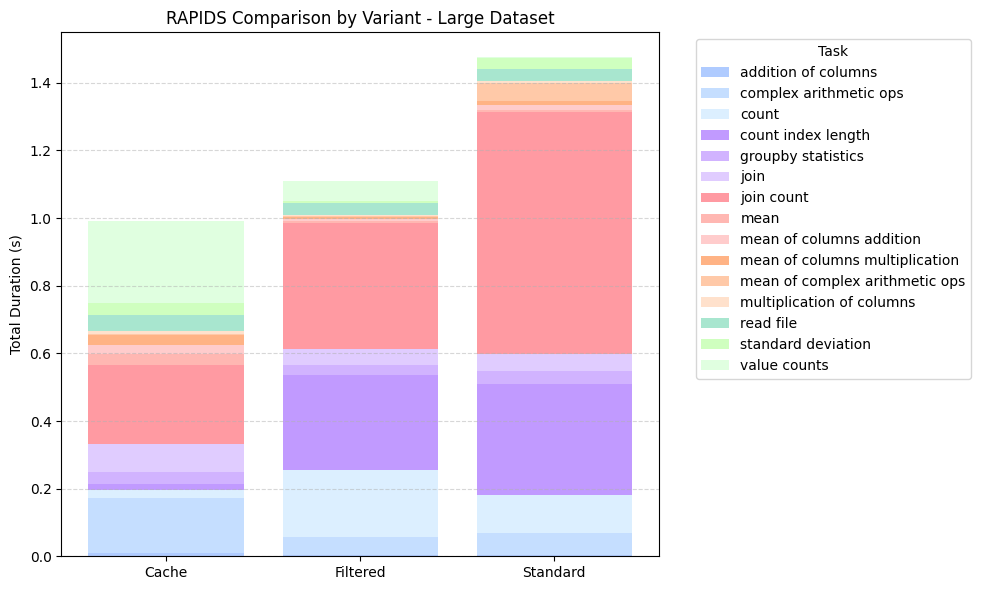

In [ ]:
custom_colors = ["#AFCBFF",  "#C5DEFF", "#DCEFFF",
                "#C19AFF",  "#D1B3FF","#E0CCFF",
                "#FF9AA2",  "#FFB7B2",  "#FFCCCC",
                "#FFB385",  "#FFC9A8", "#FFE1CC",
                "#A8E6CF",  "#CFFFBF", "#E0FFE0",
]


sizes = df_rapids['size'].unique()

for size in sizes:
    df_filtered = df_rapids[df_rapids['size'] == size]

    pivot = (
        df_filtered.groupby(['variant', 'task'])['duration']
        .sum()
        .reset_index()
        .pivot(index='variant', columns='task', values='duration')
        .fillna(0)
    )

    pivot = pivot.reset_index()
    pivot['label'] = pivot['variant'].str.capitalize()

    plt.figure(figsize=(10, 6))
    bottom = np.zeros(len(pivot))

    for i, col in enumerate(pivot.columns[1:-1]):
        plt.bar(
            pivot['label'],
            pivot[col],
            bottom=bottom,
            label=col,
            color=custom_colors[i % len(custom_colors)]
        )
        bottom += pivot[col].values

    plt.title(f'RAPIDS Comparison by Variant - {size.capitalize()} Dataset')
    plt.ylabel('Total Duration (s)')
    plt.xticks(rotation=0)
    plt.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

**Analysis**

- Small Dataset: Standard > Filtered > Cache

  - Standard (slowest):
In small datasets, orchestration/setup overhead becomes disproportionately large compared to the actual computation. RAPIDS still launches GPU operations, which include memory transfers and kernel launches — these introduce fixed costs even when data is small. In the standard variant, all operations are applied, making this overhead most visible.

  - Filtered (faster):
The filtered variant likely includes fewer operations or operates on fewer rows/columns, reducing the amount of data transferred to the GPU and the number of GPU operations required. Hence, execution time drops.

  - Cache (fastest):
The cache variant benefits from data already being loaded in GPU memory or from optimizations due to repeated access. This drastically reduces I/O and transfer overhead, making it the fastest.

- Medium Dataset: Cache > Standard > Filtered

  - Cache (slowest):
With a medium-sized dataset, caching the entire dataset into GPU memory can stress memory capacity or lead to inefficient memory management. Data may not fit neatly in memory, causing paging or delays. Also, operations that benefit from lazy evaluation (in standard) may now be forced to materialize eagerly in cache.

  - Standard (middle):
At this size, RAPIDS performs well when leveraging its normal workflow — parsing data and applying operations without forcing everything into GPU memory. It balances overhead with GPU acceleration.

  - Filtered (fastest):
Since filtered datasets are lighter, the GPU is used more efficiently. Fewer operations and less data make RAPIDS very effective, minimizing memory pressure and kernel launch overhead.

- Large Dataset: Standard > Filtered > Cache

  - Standard (slowest):
In the standard variant, RAPIDS has to process all data and all tasks, possibly pushing GPU memory limits. This causes slower performance due to memory overuse or kernel queuing.

  - Filtered (faster):
Filtered datasets contain less data, so RAPIDS can process them more efficiently. Even with large size, the workload is smaller than in the standard variant.

  - Cache (fastest):
If caching is properly managed and the data fits into GPU memory, cached large datasets allow RAPIDS to skip repeated I/O, improving execution time significantly. It avoids data transfer overhead and makes full use of GPU acceleration for all tasks.


